# Comparing Gradient Boosted Trees on Unsafe Fishermen Behaviour Prediction

## Libraries that are being used

In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns

## Importing and Preprocessing the Data

In [3]:
df = pd.read_csv('data/data-master.csv', sep=';')

print(f"The shape of the dataset: {df.shape}")
df.head(5)

The shape of the dataset: (1641, 79)


,Respondent_ID,Age,Fishing Experience,Province,Beach,Fishing Role,Experience as Head of Communities,Boat Type,Fishing Duration,Usage of LIK,...,Number of LIK Combination,Usage Persistance,Usage Duration,Frequency of Usage (min) (in month),Frequency of Usage (max) (in month),Average Frequency of Usage (in month),"Number of Prediction Made (the last month, except tsunami)","Disaster Happen (the last month, except tsunami)",Perceived of Accuracy,Action Anticipation (Respon based on LIK codes)
0,1,20,2,1,1,1,0,4,1,1,...,4,1,15,30.0,30.0,30,1,1.0,100,Ts-1: Be careful
1,1,20,2,1,1,1,0,4,1,1,...,4,1,15,30.0,30.0,30,1,1.0,100,Ts-2: Run to high place
2,1,20,2,1,1,1,0,4,1,1,...,4,1,15,30.0,30.0,30,1,1.0,100,Ts-4: Run to high place
3,1,20,2,1,1,1,0,4,1,1,...,4,1,15,30.0,30.0,30,1,1.0,100,Ts-5: Move away from beach
4,1,20,2,1,1,1,0,4,1,1,...,1,1,1,2.0,5.0,"3,5",15,11.0,"73,33333333",Wv-1: Adjust fishing equipment


In [4]:
# Filtering selected data rows

def filter_and_clean_df(df, disaster_code, target_col, demographic_cols_to_keep):
  df_filtered_rows = df[df['Action Anticipation (Respon based on LIK codes)'].str.startswith(disaster_code)].copy()
  all_current_cols = df_filtered_rows.columns.tolist()

  disaster_specific_cols = [c for c in all_current_cols if c.startswith(disaster_code)]

  cols_to_preserve_set = set(disaster_specific_cols + [target_col] + demographic_cols_to_keep)

  cols_to_drop_final = [col for col in all_current_cols if col not in cols_to_preserve_set]

  df_filtered_rows.drop(columns=cols_to_drop_final, inplace=True)

  df_filtered_rows[target_col] = df_filtered_rows[target_col].astype(str).str.strip()

  return df_filtered_rows

In [5]:
cols_to_drop = [c for c in df.columns.tolist() if not c.startswith('Wn')]

demographic_cols = [
    'Age', 'Fishing Experience', 'Province', 'Fishing Role', 'Experience as Head of Communities', 'Fishing Duration',
    'Number of Experience with Disaster', 'Level of Interaction with Disaster', 'Number of LIK Combination',
    'Usage Duration', 'Frequency of Usage (min) (in month)', 'Frequency of Usage (max) (in month)',
    'Average Frequency of Usage (in month)'
]

df = filter_and_clean_df(df, 'Wn', 'Action Anticipation (Respon based on LIK codes)', demographic_cols)

print(f"Shape of dataframe: {df.shape}")

df.head()

Shape of dataframe: (669, 31)


,Age,Fishing Experience,Province,Fishing Role,Experience as Head of Communities,Fishing Duration,Number of Experience with Disaster,Level of Interaction with Disaster,Wn-1,Wn-10,...,Wn-6,Wn-7,Wn-8,Wn-9,Number of LIK Combination,Usage Duration,Frequency of Usage (min) (in month),Frequency of Usage (max) (in month),Average Frequency of Usage (in month),Action Anticipation (Respon based on LIK codes)
8,23,3,1,1,0,1,1,2,0,0,...,0,0,0,0,2,3,3.0,4.0,"3,5",Wn-3: Adjust fishing time
9,23,3,1,1,0,1,1,2,0,0,...,0,0,0,0,2,3,3.0,4.0,"3,5",Wn-4: Adjust fishing time
10,24,2,1,1,0,1,2,5,0,0,...,0,0,0,0,3,2,16.0,20.0,18,Wn-3: Adjust fishing time
11,24,2,1,1,0,1,2,5,0,0,...,0,0,1,0,3,2,16.0,20.0,18,Wn-8: Repair boat
12,24,2,1,1,0,1,2,5,0,0,...,0,0,0,0,3,2,16.0,20.0,18,Wn-11: Be careful


In [6]:
# Preprocessing data types
unique_action_responses = df['Action Anticipation (Respon based on LIK codes)'].apply(lambda x: x.split(':')[-1].strip()).unique()
print("Unique Action Anticipation Responses:")
for response in unique_action_responses:
    print(f"- {response}")

Unique Action Anticipation Responses:
- Adjust fishing time
- Repair boat
- Be careful
- Stay alert/retrieve fishing gear
- No action
- Move away from beach
- siaga ditempat
- Stop fishing activities
- Adjust fishing equipment


In [7]:
def map_action_level(text):
    text = str(text).lower().strip()

    if any(keyword in text for keyword in [
        'move away',
        'stop fishing',
        'retrieve',
        'adjust fishing time',
        'siaga',
        'alert',
        'adjust',
        'repair boat'
    ]):
        return 1

    return 0

In [8]:
df['Target_Action_Level'] = df['Action Anticipation (Respon based on LIK codes)'].apply(map_action_level)
df.drop(columns=['Action Anticipation (Respon based on LIK codes)'], inplace=True)

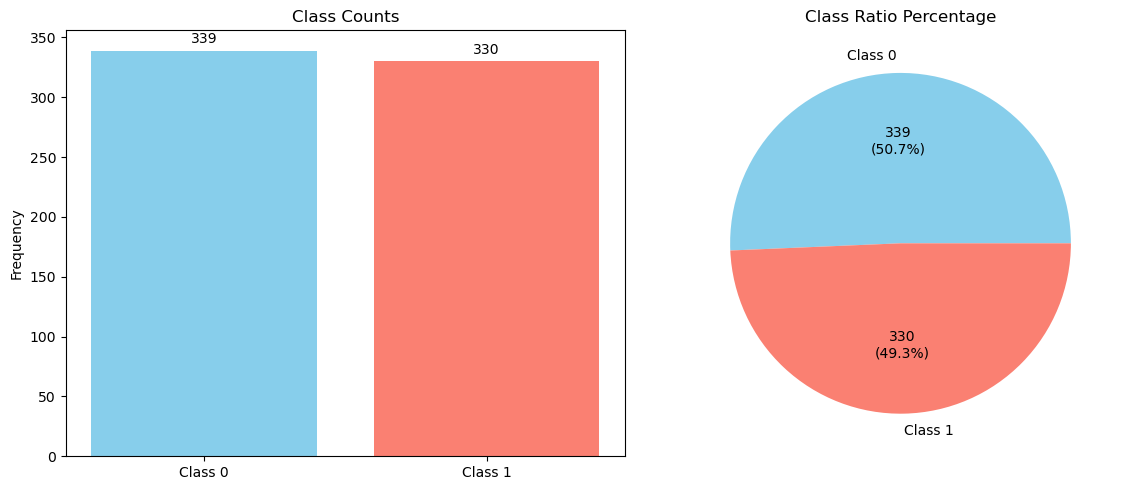

In [9]:
labels = list(df['Target_Action_Level'])
classes = sorted(list(set(labels)))
counts = [labels.count(c) for c in classes]
class_names = [f'Class {c}' for c in classes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Bar Chart
bars = ax1.bar(class_names, counts, color=['skyblue', 'salmon', 'lightgreen'])
ax1.bar_label(bars, padding=3)
ax1.set_title('Class Counts')
ax1.set_ylabel('Frequency')

# 2. Pie Chart with Raw Counts and Percentages
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{val}\n({pct:.1f}%)'
    return my_autopct

ax2.pie(counts, labels=class_names, autopct=make_autopct(counts), colors=['skyblue', 'salmon', 'lightgreen'])
ax2.set_title('Class Ratio Percentage')

plt.tight_layout()
plt.show()

In [10]:
# Making sure all the dtypes numeric
df['Average Frequency of Usage (in month)'] = df['Average Frequency of Usage (in month)'].astype(str).str.strip()
df['Average Frequency of Usage (in month)'] = pd.to_numeric(df['Average Frequency of Usage (in month)'].str.replace(',', '.'))
df['Average Frequency of Usage (in month)'] = pd.to_numeric(df['Average Frequency of Usage (in month)'])

df.info()

<class 'pandas.DataFrame'>
Index: 669 entries, 8 to 1640
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Age                                    669 non-null    int64  
 1   Fishing Experience                     669 non-null    int64  
 2   Province                               669 non-null    int64  
 3   Fishing Role                           669 non-null    int64  
 4   Experience as Head of Communities      669 non-null    int64  
 5   Fishing Duration                       669 non-null    int64  
 6   Number of Experience with Disaster     669 non-null    int64  
 7   Level of Interaction with Disaster     669 non-null    int64  
 8   Wn-1                                   669 non-null    int64  
 9   Wn-10                                  669 non-null    int64  
 10  Wn-11                                  669 non-null    int64  
 11  Wn-12                

In [11]:
# Save the processed data for modeling & shap analysis
df.to_csv('data/processed-modeling-data.csv', index=False)

## Preparing Dataset For Modeling
Apply imbalance class handling and create train + test set

In [10]:
X = df.drop(columns=['Target_Action_Level'])
y = df['Target_Action_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## XGBoost

In [12]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

train_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 150, 200, 250],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    objective='binary:logistic'
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,              
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(
    X_train, 
    y_train,
    sample_weight=train_sample_weight
)

# 5. Review Results
print("XGBOOST TUNING RESULTS")
print("="*30)
print(f"Best Parameters: {grid_search.best_params_}")

# 6. Use the Best Model for Prediction
best_xgb = grid_search.best_estimator_

Fitting 5 folds for each of 96 candidates, totalling 480 fits
XGBOOST TUNING RESULTS
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.77      0.81        71
           1       0.77      0.86      0.81        63

    accuracy                           0.81       134
   macro avg       0.82      0.82      0.81       134
weighted avg       0.82      0.81      0.81       134



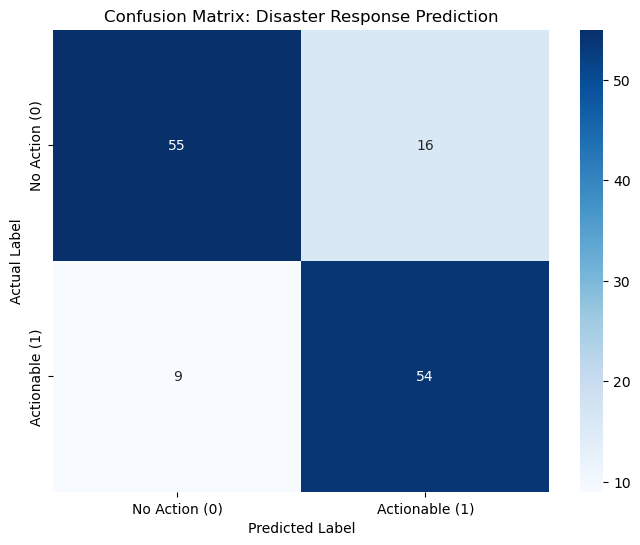

In [16]:
y_pred = best_xgb.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Action (0)', 'Actionable (1)'],
            yticklabels=['No Action (0)', 'Actionable (1)'])

plt.title('Confusion Matrix: Disaster Response Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [17]:
# Save the model
best_xgb.save_model('models/xgb_behavioural.json')

## Catboost

In [12]:
from catboost import CatBoostClassifier

train_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

cat_model = CatBoostClassifier(
    loss_function='Logloss',
    random_seed=42,
    logging_level='Silent',
    thread_count=-1
)

param_grid = {
    'iterations': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [32, 64, 128]
}

grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train, sample_weight=train_sample_weight)

print("CATBOOST TUNING RESULTS")
print("="*30)
print(f"Best Parameters: {grid_search.best_params_}")

best_cat = grid_search.best_estimator_

CATBOOST TUNING RESULTS
Best Parameters: {'border_count': 64, 'depth': 6, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.1}


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.70      0.77        71
           1       0.72      0.86      0.78        63

    accuracy                           0.78       134
   macro avg       0.78      0.78      0.78       134
weighted avg       0.79      0.78      0.78       134



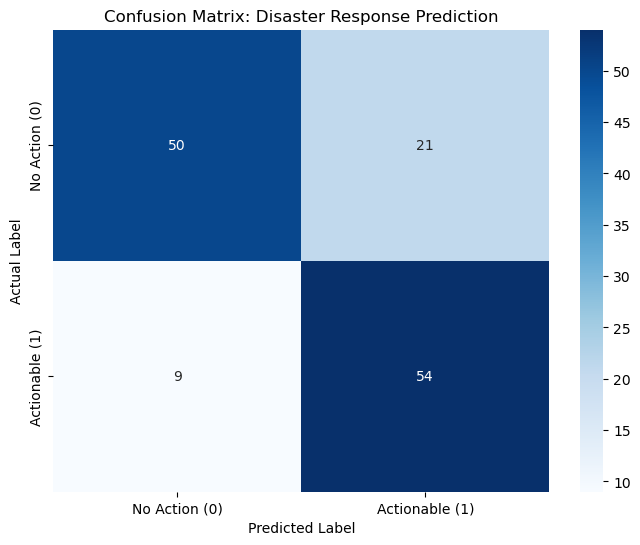

In [13]:
y_pred = best_cat.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Action (0)', 'Actionable (1)'],
            yticklabels=['No Action (0)', 'Actionable (1)'])

plt.title('Confusion Matrix: Disaster Response Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [14]:
# Save the model
best_cat.save_model('models/cat_behavioural.json')

## LightGBM

In [23]:
from lightgbm import LGBMClassifier

param_grid_lgb = {
    'max_depth': [3, 4, 6],
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'min_child_samples': [10, 20, 30]
}

grid_lgb = GridSearchCV(
    estimator=LGBMClassifier(objective='binary', random_state=42, verbosity=-1),
    param_grid=param_grid_lgb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lgb.fit(X_train, y_train, sample_weight=train_sample_weight)
best_lgb = grid_lgb.best_estimator_

print(f"Best LightGBM Params: {grid_lgb.best_params_}")

Best LightGBM Params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_samples': 10, 'n_estimators': 300, 'num_leaves': 15}


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.69      0.75        71
           1       0.71      0.84      0.77        63

    accuracy                           0.76       134
   macro avg       0.77      0.77      0.76       134
weighted avg       0.77      0.76      0.76       134



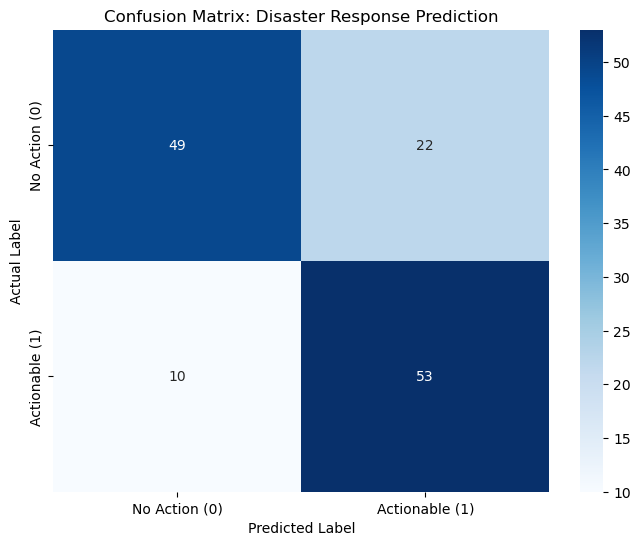

In [25]:
y_pred = best_lgb.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Action (0)', 'Actionable (1)'],
            yticklabels=['No Action (0)', 'Actionable (1)'])

plt.title('Confusion Matrix: Disaster Response Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [26]:
joblib.dump(best_lgb, 'lgb_behavioural.pkl')

['lgb_behavioural.pkl']

## Model Performance Summary

| Model    | Accuracy | Precision (Class 0) | Recall (Class 0) | F1-Score (Class 0) | F1-Macro |
|:---------|:---------|:--------------------|:-----------------|:-------------------|:---------|
| XGBoost  | 0.81     | 0.86                | 0.77             | 0.81               | 0.81     |
| CatBoost | 0.78     | 0.85                | 0.70             | 0.77               | 0.78     |
| LightGBM | 0.76     | 0.83                | 0.69             | 0.75               | 0.76     |


The experimental results demonstrate that the XGBoost architecture significantly outperforms CatBoost and LightGBM in predicting unsafe fisherman behavior within a binary classification framework. XGBoost achieved a balanced F1-Macro score of 0.81 and the highest Recall of 0.77 for the critical "Unsafe/No Action" category (Class 0). While CatBoost and LightGBM maintained respectable precision levels (0.85 and 0.83, respectively), they failed to match the sensitivity of XGBoost in capturing high-risk individuals. This high precision across all models ensures the system's reliability by minimizing false positives, while the superior recall of XGBoost confirms its suitability as the core engine for coastal disaster early warning systems.